In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pymaster as nmt
import healpy as hp

In [4]:
def logspace(a, b, c): # minimum, maximum, and number of values
    t = (b/a)**(1/c)
    return a*t**np.arange(c)

def logbinning(lmin, lmax, lbin):
    
    ls = np.arange(lmax) # array of ls.
    weights = 1/lbin*np.ones_like(ls) # weights within a bin; equally spread in this case.
    bpws = -1 + np.zeros_like(ls) # array of bandpower indices; starts with -1 because
                                  # we don't want to take into account the first 30 multipoles.
    j = lbin
    division = logspace(lmin, lmax, lbin)
    for i in range(lbin):
        while j < division[i]:
            bpws[j] += i
            j += 1
    i += 1
    while j < lmax:
        bpws[j] += i
        j += 1
    return ls, weights, bpws

def get_bins_n_leff(lmin,lmax,lbin):
    ls, weights, bpws = logbinning(lmin,lmax,lbin)
    binning = nmt.NmtBin(bpws=bpws, ells=ls, weights=weights)
    leff = binning.get_effective_ells()
    return binning, leff

def read_wcount_maps(zbins):
    m = []
    for i in range(len(zbins)):
        m.append(hp.read_map(f'redmagic_maps_nside1024/wcountsmap_zbin{i}.fits', 
                             field=0, dtype=np.float64, verbose=False))
    return m

def read_count_maps(zbins):
    m = []
    for i in range(len(zbins)):
        m.append(hp.read_map(f'redmagic_maps_nside1024/countsmap_zbin{i}.fits', 
                             field=(0), dtype=np.float64, verbose=False))
    return m

def read_shear_maps(zbins):
    g1_map = []
    g2_map = []
    for i in range(len(zbins)):
        g1_map.append(hp.read_map(f'metacal_maps_nside1024/g1map_zbin{i}.fits', 
                            field=(0), verbose=False, dtype=np.float64))
        g2_map.append(hp.read_map(f'metacal_maps_nside1024/g2map_zbin{i}.fits', 
                            field=(0), verbose=False, dtype=np.float64))
    return [g1_map, g2_map]

In [5]:
binning, leff = get_bins_n_leff(30, 3000, 20)

In [7]:
wc = hp.read_map(f'redmagic_maps_nside1024/wcountsmap_zbin{0}.fits', field=(0), verbose=False, dtype=np.float64)
nc = hp.read_map(f'redmagic_maps_nside1024/countsmap_zbin{0}.fits', field=(0), verbose=False, dtype=np.float64)

In [8]:
w = np.zeros(len(nc))
for i in range(len(w)):
    if wc[i] or nc[i] != 0:
        w[i] = wc[i]/nc[i]
print(len(w))
nbar = sum(wc)/sum(w)

12582912


In [9]:
print(nbar)
np.mean(nc[nc>0])

1.1525331005261548


1.1533268172603532

In [34]:
d = np.zeros(len(wc))
d[w>0] = wc[w>0]/(nbar*w[w>0]) - 1

12582912
12582912


In [36]:
print('reading redmagic mask')
mask = hp.read_map(f'redmagic_maps_nside1024/maskmap.fits')
print('reading redmagic map (zbin1)')
print('creating field')
f0 = nmt.NmtField(mask, [d])

reading redmagic mask
NSIDE = 1024
ORDERING = RING in fits file
INDXSCHM = IMPLICIT
reading redmagic map (zbin1)
creating field


In [37]:
cl00 = nmt.compute_full_master(f0, f0, binning)
print(f'the cl shape is {cl00.shape}')

the cl shape is (1, 20)


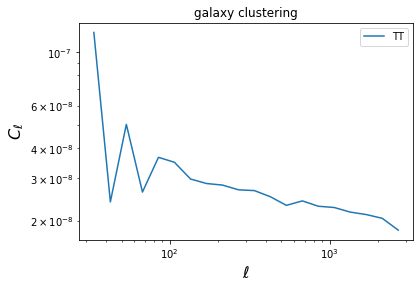

In [39]:
plt.plot(leff, cl00[0], label='TT')
# plt.loglog(leff, abs(cl02[0]), label='TE')
# plt.loglog(leff, abs(cl02[1]), label='TB')
# plt.loglog(leff, cl22[0], label='EE')
# plt.loglog(leff, cl22[3], label='BB')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.legend(loc='upper right', ncol=2, labelspacing=0.1)
plt.title('galaxy clustering')
# plt.savefig('../plots/myggmap_zbin4_mask3_1024.png')
plt.show()

In [40]:
# HUGO'S MAPS TEST

print('reading metacal mask (zbin4)')
mask = hp.read_map(f'metacal_maps_nside1024/maskmap_zbin{3}.fits')
print('reading metacal maps (zbin4)')
g1 = hp.read_map(f'metacal_maps_nside1024/g1map_zbin{3}.fits', field=(0), verbose=False, dtype=np.float64)
g2 = hp.read_map(f'metacal_maps_nside1024/g2map_zbin{3}.fits', field=(0), verbose=False, dtype=np.float64)
print(f'g1 = {np.mean(g1)} +- {np.std(g1)} and g2 = {np.mean(g2)} +- {np.std(g2)}')

reading metacal mask (zbin4)
NSIDE = 1024
ORDERING = RING in fits file
INDXSCHM = IMPLICIT
reading metacal maps (zbin4)


/home/lucas/anaconda3/lib/python3.7/site-packages/healpy/fitsfunc.py:352: UserWarning: If you are not specifying the input dtype and using the default np.float64 dtype of read_map(), please consider that it will change in a future version to None as to keep the same dtype of the input file: please explicitly set the dtype if it is important to you.
  "If you are not specifying the input dtype and using the default "


g1 = 4.549473139071428e-13 +- 0.09594452604578055 and g2 = 7.394509063765077e-13 +- 0.09651013969096163


In [57]:
print('creating field')
f2 = nmt.NmtField(mask, [g1,g2], purify_e=False, purify_b=False)

print(f'g1 = {np.mean(g1)} +- {np.std(g1)} and g2 = {np.mean(g2)} +- {np.std(g2)}')

creating field
g1 = 4.549473139071428e-13 +- 0.09594452604578055 and g2 = 7.394509063765077e-13 +- 0.09651013969096163


In [49]:
cl02 = nmt.compute_full_master(f0, f2, binning)
print(f'the cl shape is {cl02.shape}')

the cl shape is (2, 20)


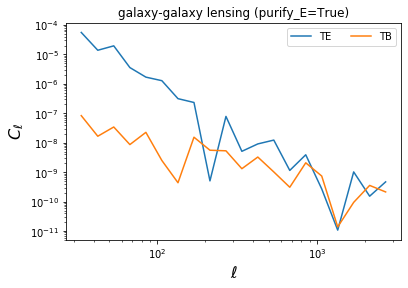

In [51]:
# plt.plot(leff, cl00[0], label='TT')
plt.loglog(leff, abs(cl02[0]), label='TE')
plt.loglog(leff, abs(cl02[1]), label='TB')
# plt.loglog(leff, cl22[0], label='EE')
# plt.loglog(leff, cl22[3], label='BB')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.legend(loc='upper right', ncol=2, labelspacing=0.1)
plt.title('galaxy-galaxy lensing (purify_E=True)')
# plt.savefig('../plots/myggmap_zbin4_mask3_1024.png')
plt.show()

In [10]:
# FLASK MAPS TEST

mask = hp.read_map(f'metacal_maps_nside1024/maskmap_zbin1.fits')
gg = hp.read_map(f'../../srvdatatransfer.linea.gov.br/seed1/kgg-s1-f2z1.fits', field=(1,2), verbose=False, dtype=np.float64)
gg = hp.ud_grade(gg,1024)
print(f'g1 = {np.mean(gg)} +- {np.std(gg)} and g2 = {np.mean(gg)} +- {np.std(gg)}')

NSIDE = 1024
ORDERING = RING in fits file
INDXSCHM = IMPLICIT
g1 = 2.5441466146481456e-06 +- 0.0033454648551094483 and g2 = 2.5441466146481456e-06 +- 0.0033454648551094483


In [11]:
gg.shape

(2, 12582912)

In [12]:
f2 = nmt.NmtField(mask, gg, purify_e=False, purify_b=False)

In [13]:
cl22 = nmt.compute_full_master(f2, f2, binning)
print(f'the cl shape is {cl22.shape}')

the cl shape is (4, 20)


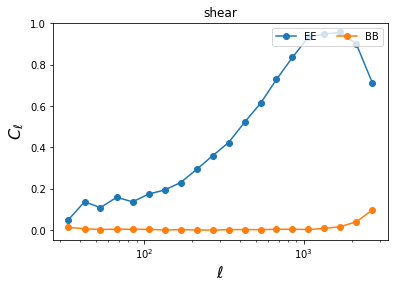

In [22]:
# plt.plot(leff, cl00[0], label='TT')
# plt.loglog(leff, abs(cl22[0]), label='TE')
# plt.loglog(leff, abs(cl22[1]), label='TB')
plt.plot(leff, leff*(leff+1)*cl22[0]/(2*np.pi)*1e5, label='EE',marker='o')
plt.plot(leff, leff*(leff+1)*cl22[3]/(2*np.pi)*1e5, label='BB',marker='o')
plt.xscale('log')
# plt.yscale('log')
plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.legend(loc='upper right', ncol=2, labelspacing=0.1)
plt.title('shear')
# plt.savefig('../plots/myggmap_zbin4_mask3_1024.png')
plt.show()

In [58]:
cl22 = nmt.compute_full_master(f2, f2, binning)
print(f'the cl shape is {cl22.shape}')

the cl shape is (4, 20)


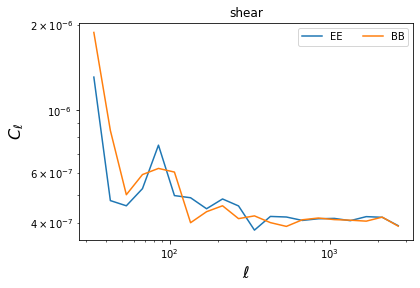

In [59]:
# plt.plot(leff, cl00[0], label='TT')
# plt.loglog(leff, abs(cl02[0]), label='TE')
# plt.loglog(leff, abs(cl02[1]), label='TB')
plt.loglog(leff, cl22[0], label='EE')
plt.loglog(leff, cl22[3], label='BB')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.legend(loc='upper right', ncol=2, labelspacing=0.1)
plt.title('shear')
# plt.savefig('../plots/myggmap_zbin4_mask3_1024.png')
plt.show()

In [5]:
ggmap = hp.read_map('../myggmap/ggmap_mcal-y1a1-combined-riz-unblind-v4-matched_nside1024_ggmap_zbin4.fits', field=(0,1))
g1, g2 = ggmap[0], ggmap[1]
print(f'g1 = {np.mean(g1)} +- {np.std(g1)} and g2 = {np.mean(g2)} +- {np.std(g2)}')

NSIDE = 1024
ORDERING = RING in fits file
INDXSCHM = IMPLICIT
g1 = -0.002955431240876718 +- 28.66139722100873 and g2 = 0.010648701601723284 +- 33.734984227704125


In [6]:
# HUGO'S MAPS TEST

# print('reading redmagic mask')
# mask = hp.read_map(f'redmagic_maps_nside1024/maskmap.fits')
# print('creating field')
# f0 = nmt.NmtField(mask, [d], purify_e=False, purify_b=False)

print('reading metacal mask (zbin4)')
mask = hp.read_map(f'metacal_maps_nside1024/maskmap_zbin{3}.fits')
print('creating field')
f2 = nmt.NmtField(mask, [g1,g2], purify_e=True, purify_b=False)

reading metacal mask (zbin4)
NSIDE = 1024
ORDERING = RING in fits file
INDXSCHM = IMPLICIT
creating field


In [8]:
cl22 = nmt.compute_full_master(f2, f2, binning)
print(f'the cl shape is {cl22.shape}')

the cl shape is (4, 20)


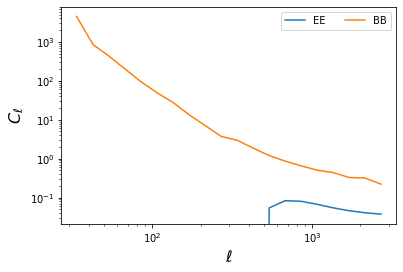

In [14]:
# plt.plot(leff, cl00[0], label='TT')
# plt.loglog(leff, abs(cl02[0]), label='TE')
# plt.loglog(leff, abs(cl02[1]), label='TB')
plt.loglog(leff, cl22[0], label='EE')
plt.loglog(leff, cl22[3], label='BB')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.legend(loc='upper right', ncol=2, labelspacing=0.1)
# plt.savefig('../plots/myggmap_zbin4_mask3_1024.png')
plt.show()

g1 = 4.549473139071428e-13 +- 0.09594452604578055 and g2 = 7.394509063765077e-13 +- 0.09651013969096163


In [ ]:
wc = hp.read_map(f'redmagic_maps_nside1024/wcountsmap_zbin{0}.fits', field=(0))
nc = hp.read_map(f'redmagic_maps_nside1024/countsmap_zbin{0}.fits', field=(0))

w = np.zeros(len(nc))
for i in range(len(w)):
    if wc[i] or nc[i] != 0:
        w[i] = wc[i]/nc[i]
        
nbar = sum(wc)/sum(w)
d = wc/(nbar*w) - 1

mask = hp.read_map(f'redmagic_maps_nside1024/maskmap.fits')
f0 = nmt.NmtField(mask, [d])

cl00 = nmt.compute_full_master(f0, f0, binning)

plt.plot(leff, cl00[0], label='TT')
# plt.loglog(leff, abs(cl02[0]), label='TE')
# plt.loglog(leff, abs(cl02[1]), label='TB')
# plt.loglog(leff, cl22[0], label='EE')
# plt.loglog(leff, cl22[3], label='BB')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.legend(loc='upper right', ncol=2, labelspacing=0.1)
plt.show()

In [ ]:
mask = hp.read_map(f'metacal_maps_nside1024/maskmap_zbin{3}.fits')
g1 = hp.read_map(f'metacal_maps_nside1024/g1map_zbin{3}.fits', field=(0))
g2 = hp.read_map(f'metacal_maps_nside1024/g2map_zbin{3}.fits', field=(0))
print(f'g1 = {np.mean(g1)} +- {np.std(g1)} and g2 = {np.mean(g2)} +- {np.std(g2)}')

f2 = nmt.NmtField(mask, [g1,g2], purify_e=True, purify_b=False)

cl02 = nmt.compute_full_master(f0, f2, binning)

# plt.plot(leff, cl00[0], label='TT')
plt.loglog(leff, abs(cl02[0]), label='TE')
plt.loglog(leff, abs(cl02[1]), label='TB')
# plt.loglog(leff, cl22[0], label='EE')
# plt.loglog(leff, cl22[3], label='BB')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.legend(loc='upper right', ncol=2, labelspacing=0.1)
plt.show()

In [ ]:
mask = hp.read_map(f'metacal_maps_nside1024/maskmap_zbin{3}.fits')
g1 = hp.read_map(f'metacal_maps_nside1024/g1map_zbin{3}.fits', field=(0))
g2 = hp.read_map(f'metacal_maps_nside1024/g2map_zbin{3}.fits', field=(0))
print(f'g1 = {np.mean(g1)} +- {np.std(g1)} and g2 = {np.mean(g2)} +- {np.std(g2)}')

f2 = nmt.NmtField(mask, [g1,g2], purify_e=True, purify_b=False)

cl22 = nmt.compute_full_master(f2, f2, binning)

# plt.plot(leff, cl00[0], label='TT')
# plt.loglog(leff, abs(cl02[0]), label='TE')
# plt.loglog(leff, abs(cl02[1]), label='TB')
plt.loglog(leff, cl22[0], label='EE')
plt.loglog(leff, cl22[3], label='BB')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.legend(loc='upper right', ncol=2, labelspacing=0.1)
plt.show()